In [1]:
import pandas as pd
from google.colab import files
import io

print("Please upload your CSV file.")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

Please upload your CSV file.


Saving nykaa_campaign_data.csv to nykaa_campaign_data.csv
User uploaded file "nykaa_campaign_data.csv" with length 7600393 bytes


The CSV file has been loaded into a pandas DataFrame named `df`. Here are the first 5 rows:

In [2]:
display(df.head())

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024


In [3]:
df.head()
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

,0
Campaign_ID,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Impressions,0
Clicks,0
Leads,0
Conversions,0
Revenue,0


In [4]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Campaign_ID       55555 non-null  object        
 1   Campaign_Type     55555 non-null  object        
 2   Target_Audience   55555 non-null  object        
 3   Duration          55555 non-null  int64         
 4   Channel_Used      55555 non-null  object        
 5   Impressions       55555 non-null  int64         
 6   Clicks            55555 non-null  int64         
 7   Leads             55555 non-null  int64         
 8   Conversions       55555 non-null  int64         
 9   Revenue           55555 non-null  int64         
 10  Acquisition_Cost  55555 non-null  float64       
 11  ROI               55555 non-null  float64       
 12  Language          55555 non-null  object        
 13  Engagement_Score  55555 non-null  float64       
 14  Customer_Segment  5555

In [5]:
# Total Revenue
total_revenue = df['Revenue'].sum()

# Total Campaigns
total_campaigns = df['Campaign_ID'].nunique()

# Conversion Rate
conversion_rate = (df['Conversions'].sum() / df['Clicks'].sum()) * 100

# Click Through Rate (CTR)
ctr = (df['Clicks'].sum() / df['Impressions'].sum()) * 100

# Average ROI
avg_roi = df['ROI'].mean()

print("Total Revenue:", round(total_revenue,2))
print("Total Campaigns:", total_campaigns)
print("Conversion Rate:", round(conversion_rate,2),"%")
print("CTR:", round(ctr,2),"%")
print("Average ROI:", round(avg_roi,2))

Total Revenue: 28656364282
Total Campaigns: 55555
Conversion Rate: 22.03 %
CTR: 8.51 %
Average ROI: 2.71


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


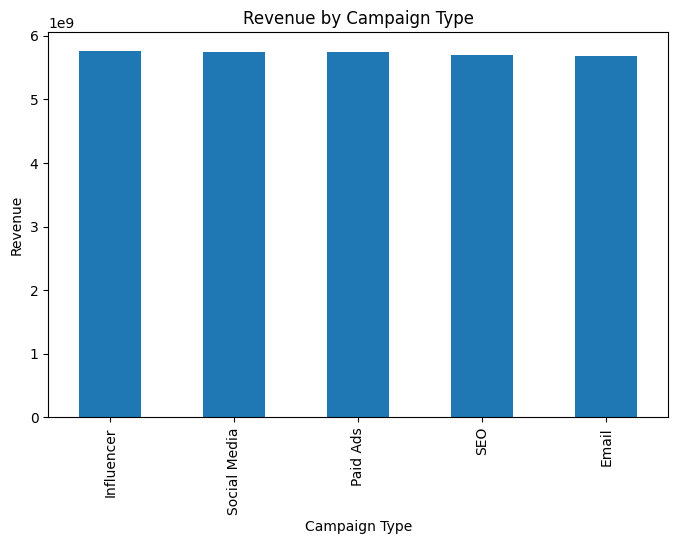

In [18]:
plt.figure(figsize=(8,5))
revenue_campaign.plot(kind='bar')

plt.title('Revenue by Campaign Type')
plt.ylabel('Revenue')
plt.xlabel('Campaign Type')

plt.savefig("revenue_by_campaign_type.png", bbox_inches='tight')

plt.show()

In [8]:
revenue_campaign = df.groupby('Campaign_Type')['Revenue'].sum().sort_values(ascending=False)

print(revenue_campaign)

Campaign_Type
Influencer      5769064044
Social Media    5751837620
Paid Ads        5751468983
SEO             5698831847
Email           5685161788
Name: Revenue, dtype: int64


In [9]:
roi_campaign = df.groupby('Campaign_Type')['ROI'].mean().sort_values(ascending=False)

print(roi_campaign)

Campaign_Type
Social Media    2.754784
Paid Ads        2.722275
SEO             2.709630
Influencer      2.699687
Email           2.682663
Name: ROI, dtype: float64


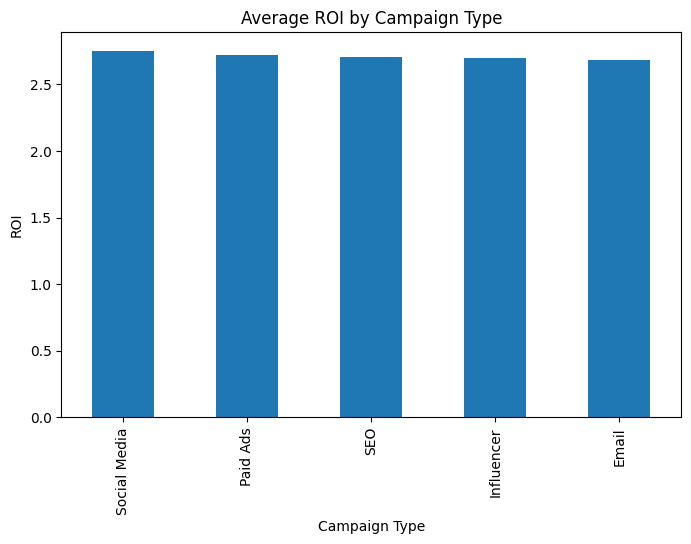

In [19]:
plt.figure(figsize=(8,5))
roi_campaign.plot(kind='bar')

plt.title('Average ROI by Campaign Type')
plt.ylabel('ROI')
plt.xlabel('Campaign Type')

plt.savefig("roi_by_campaign_type.png", bbox_inches='tight')

plt.show()

In [11]:
conversion_campaign = (
    df.groupby('Campaign_Type')[['Conversions', 'Clicks']]
    .sum()
)

conversion_campaign['Conversion_Rate'] = (
    conversion_campaign['Conversions']
    / conversion_campaign['Clicks']
) * 100

conversion_campaign = conversion_campaign.sort_values(
    by='Conversion_Rate',
    ascending=False
)

print(conversion_campaign[['Conversion_Rate']])

               Conversion_Rate
Campaign_Type                 
Email                22.115280
Social Media         22.077791
Influencer           22.049900
SEO                  22.028197
Paid Ads             21.888342


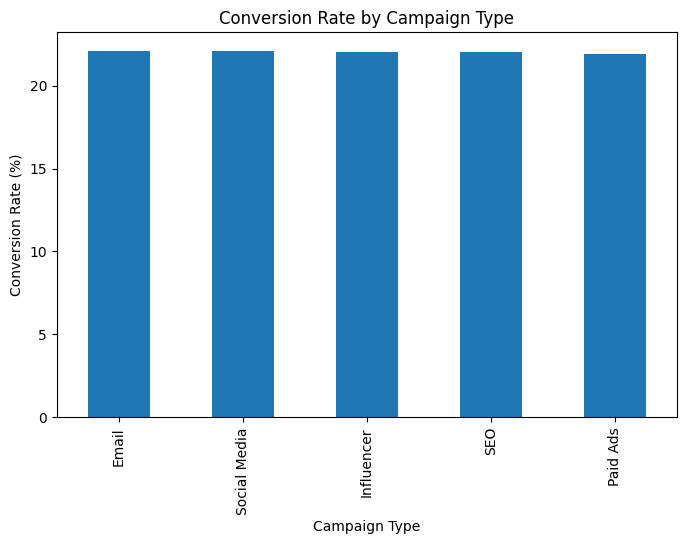

In [20]:
plt.figure(figsize=(8,5))

conversion_campaign['Conversion_Rate'].plot(
    kind='bar'
)

plt.title('Conversion Rate by Campaign Type')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Campaign Type')

plt.savefig("conversion_rate_by_campaign_type.png", bbox_inches='tight')

plt.show()

In [13]:
campaign_health = df.groupby('Campaign_Type').agg({
    'ROI':'mean',
    'Engagement_Score':'mean',
    'Revenue':'sum'
}).reset_index()

# Normalize values between 0 and 100
campaign_health['ROI_Score'] = (
    campaign_health['ROI']
    / campaign_health['ROI'].max()
) * 100

campaign_health['Engagement_Score_Norm'] = (
    campaign_health['Engagement_Score']
    / campaign_health['Engagement_Score'].max()
) * 100

campaign_health['Revenue_Score'] = (
    campaign_health['Revenue']
    / campaign_health['Revenue'].max()
) * 100

# Health Score Formula
campaign_health['Health_Score'] = (
    campaign_health['ROI_Score'] * 0.4 +
    campaign_health['Engagement_Score_Norm'] * 0.3 +
    campaign_health['Revenue_Score'] * 0.3
)

campaign_health = campaign_health.sort_values(
    by='Health_Score',
    ascending=False
)

print(
    campaign_health[
        ['Campaign_Type','Health_Score']
    ]
)

  Campaign_Type  Health_Score
4  Social Media     99.876696
1    Influencer     99.199986
2      Paid Ads     99.199034
3           SEO     98.658367
0         Email     98.270370


In [14]:
top_campaign = campaign_health.iloc[0]['Campaign_Type']

print("AI Recommendation:")
print(f"Increase investment in {top_campaign} campaigns because they show the strongest overall performance based on Revenue, ROI, and Engagement Score.")

AI Recommendation:
Increase investment in Social Media campaigns because they show the strongest overall performance based on Revenue, ROI, and Engagement Score.


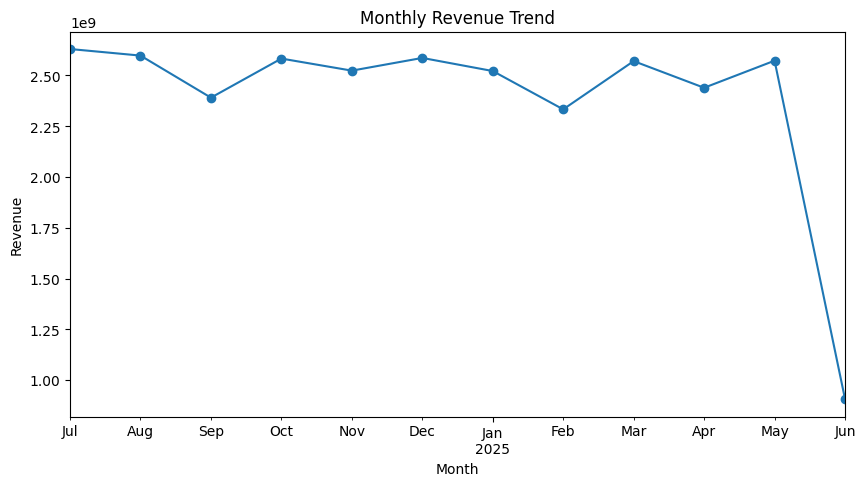

In [21]:
monthly_revenue = df.groupby(
    df['Date'].dt.to_period('M')
)['Revenue'].sum()

monthly_revenue.plot(
    kind='line',
    figsize=(10,5),
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.xlabel('Month')

plt.savefig("monthly_revenue_trend.png", bbox_inches='tight')

plt.show()

In [16]:
segment_revenue = df.groupby(
    'Customer_Segment'
)['Revenue'].sum().sort_values(ascending=False)

print(segment_revenue)

Customer_Segment
Working Women            5811927015
College Students         5799502690
Premium Shoppers         5709910379
Tier 2 City Customers    5691846274
Youth                    5643177924
Name: Revenue, dtype: int64


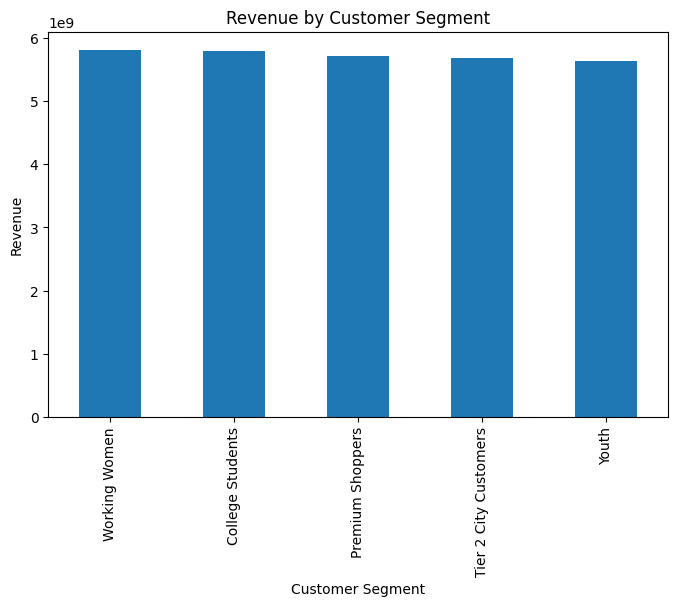

In [22]:
plt.figure(figsize=(8,5))

segment_revenue.plot(
    kind='bar'
)

plt.title('Revenue by Customer Segment')
plt.ylabel('Revenue')
plt.xlabel('Customer Segment')

plt.savefig("customer_segment_revenue.png", bbox_inches='tight')

plt.show()

In [23]:
from google.colab import files
files.download("revenue_by_campaign_type.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
files.download("roi_by_campaign_type.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
files.download("conversion_rate_by_campaign_type.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
files.download("monthly_revenue_trend.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
files.download("customer_segment_revenue.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Business Insights

1. Social Media campaigns achieved the highest ROI (2.75), making them the most cost-effective campaign type.

2. Email campaigns achieved the highest Conversion Rate (22.12%), indicating strong customer conversion efficiency.

3. Influencer campaigns generated the highest total revenue among all campaign types.

4. Social Media campaigns achieved the highest Campaign Health Score, demonstrating a strong balance of revenue, ROI, and engagement.

5. Working Women generated the highest revenue among customer segments, making them the most valuable target audience.

6. Revenue distribution remained relatively balanced across campaign types, indicating a diversified marketing strategy.